<a href="https://colab.research.google.com/github/siyal-sss/Cardiovascular-Risk-Prediction/blob/main/acute_myocardial_infarction_transcriptomics_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install GEOparse

In [2]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 11.0 MB/s eta 0:00:00


In [3]:
import GEOparse
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import gseapy as gp
import os

print("Everything loaded")

Everything loaded


In [4]:
!pip install GEOparse gseapy statsmodels seaborn scikit-learn openpyxl

In [5]:
gse = GEOparse.get_GEO(
    geo="GSE66360",
    destdir="./"
)

print("Dataset loaded")

20-Jun-2026 08:23:09 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
20-Jun-2026 08:23:09 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE66nnn/GSE66360/soft/GSE66360_family.soft.gz to ./GSE66360_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE66nnn/GSE66360/soft/GSE66360_family.soft.gz to ./GSE66360_family.soft.gz
100%|██████████| 68.5M/68.5M [00:00<00:00, 79.4MB/s]
20-Jun-2026 08:23:10 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
20-Jun-2026 08:23:10 DEBUG downloader - Moving /tmp/tmpyz42vek4 to /content/GSE66360_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpyz42vek4 to /content/GSE66360_family.soft.gz
20-Jun-2026 08:23:10 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE66nnn/GSE66360/soft/GSE66360_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE66nnn/GSE66

Dataset loaded


In [6]:
samples = {}

for gsm_name, gsm in gse.gsms.items():
    samples[gsm_name] = gsm.table


expression = pd.concat(
    [x.set_index("ID_REF")["VALUE"] for x in samples.values()],
    axis=1
)

expression.columns = samples.keys()


print(expression.shape)

expression.head()

(54675, 99)


,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,GSM1620824,GSM1620825,GSM1620826,GSM1620827,GSM1620828,...,GSM1620908,GSM1620909,GSM1620910,GSM1620911,GSM1620912,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.866378,4.948736,5.148384,5.064419,5.017833,5.116154,5.431328,5.235271,5.773528,6.016415,...,5.419482,5.057716,5.996493,5.343133,5.558892,6.472517,5.678816,5.653286,6.013841,5.465334
1053_at,8.225790,7.525865,7.764637,7.198461,7.831450,7.203592,7.694551,7.760259,8.279814,7.580841,...,7.226348,7.105538,5.354105,8.271500,5.963346,8.261422,6.925753,7.918424,7.442701,9.225221
117_at,6.179732,6.628137,5.859151,5.974135,6.793079,6.435229,6.320546,6.483590,6.387779,6.307066,...,6.789501,7.441940,7.026929,6.003973,7.474326,6.367759,6.835756,7.577035,7.147417,6.481128
121_at,6.179478,6.582889,6.602135,6.545905,5.911542,6.285420,6.562316,6.345888,6.272806,5.971847,...,6.513437,6.317523,7.413453,6.809103,5.949091,6.440978,6.955883,6.499215,6.587065,6.897591
1255_g_at,2.792048,2.695714,2.580181,2.712124,2.723687,2.706684,2.674747,2.635150,2.696649,2.802863,...,2.924658,2.714103,3.635945,2.710944,2.979381,3.730139,2.914868,3.013901,2.729320,3.151449


In [7]:
metadata = []

for gsm_name, gsm in gse.gsms.items():

    title = " ".join(
        gsm.metadata["title"]
    )

    metadata.append(
        {
            "sample":gsm_name,
            "title":title
        }
    )


metadata = pd.DataFrame(metadata)

metadata.head()

,sample,title
0,GSM1620819,Muse_1_DISCOVERY_Control
1,GSM1620820,Muse_2_DISCOVERY_Control
2,GSM1620821,Muse_3_DISCOVERY_Control
3,GSM1620822,Muse_4_DISCOVERY_Control
4,GSM1620823,Muse_5_DISCOVERY_Control


In [8]:
metadata["group"] = metadata["title"].apply(
    lambda x:
    "AMI"
    if "MI" in x.upper()
    or "INFARCTION" in x.upper()
    else "Control"
)


metadata["group"].value_counts()

,count
group,
Control,50
AMI,49


In [9]:
expression = expression[
    metadata["sample"]
]


expression = np.log2(
    expression.astype(float)+1
)


expression.head()

,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,GSM1620824,GSM1620825,GSM1620826,GSM1620827,GSM1620828,...,GSM1620908,GSM1620909,GSM1620910,GSM1620911,GSM1620912,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,2.779549,2.572583,2.620207,2.600369,2.589244,2.612625,2.685117,2.640452,2.759908,2.810734,...,2.682457,2.598774,2.806632,2.665196,2.713452,2.901594,2.739592,2.734067,2.810205,2.692725
1053_at,3.205672,3.091846,3.131694,3.035353,3.142650,3.036256,3.120111,3.130974,3.214096,3.101119,...,3.040252,3.018908,2.667689,3.212803,2.799781,3.211234,2.986548,3.156789,3.077705,3.354060
117_at,2.843930,2.931331,2.778030,2.802014,2.962193,2.894377,2.871951,2.903731,2.885141,2.869292,...,2.961531,3.077575,3.004848,2.808173,3.083099,2.881226,2.970072,3.100479,3.026343,2.903256
121_at,2.843879,2.922748,2.926405,2.915694,2.789008,2.865012,2.918828,2.876937,2.862512,2.801541,...,2.909473,2.871355,3.072698,2.965157,2.796824,2.895492,2.992022,2.906740,2.923542,2.981413
1255_g_at,1.922977,1.885853,1.840033,1.892245,1.896732,1.890129,1.877645,1.862015,1.886218,1.927086,...,1.972567,1.893014,2.212863,1.891786,1.992544,2.241883,1.968964,2.005005,1.898913,2.053615


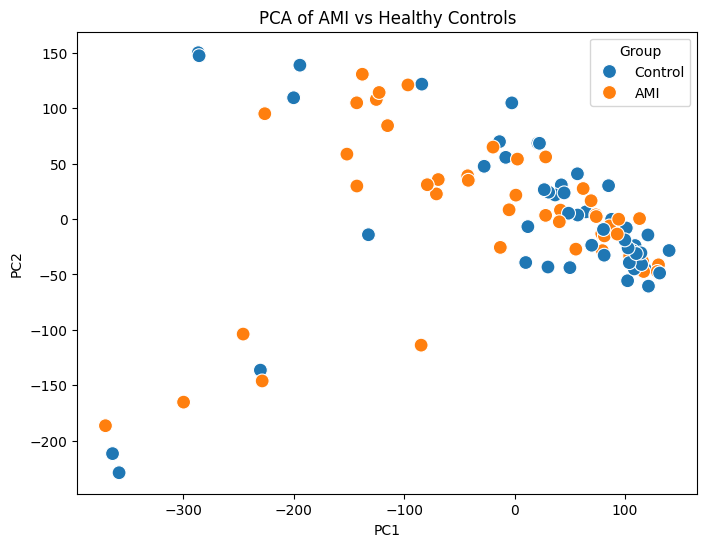

In [10]:
X = expression.T


scaled = StandardScaler().fit_transform(X)


pca = PCA(
    n_components=2
)


pc = pca.fit_transform(scaled)


pca_df = pd.DataFrame(
    pc,
    columns=["PC1","PC2"]
)


pca_df["Group"] = metadata["group"].values


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Group",
    s=100
)

plt.title(
    "PCA of AMI vs Healthy Controls"
)

plt.show()

In [11]:
# Differential expression analysis

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


# Separate samples

ami_samples = metadata[
    metadata["group"]=="AMI"
]["sample"]


control_samples = metadata[
    metadata["group"]=="Control"
]["sample"]



deg_results = []


# test every gene

for gene, row in expression.iterrows():

    ami_expression = row[ami_samples]

    control_expression = row[control_samples]


    # Welch t-test
    stat, pvalue = ttest_ind(
        ami_expression,
        control_expression,
        equal_var=False
    )


    # log2 fold change
    logFC = (
        ami_expression.mean()
        -
        control_expression.mean()
    )


    deg_results.append(
        [
            gene,
            logFC,
            pvalue
        ]
    )



# create dataframe

deg = pd.DataFrame(
    deg_results,
    columns=[
        "Gene",
        "logFC",
        "pvalue"
    ]
)


deg.head()

,Gene,logFC,pvalue
0,1007_s_at,-0.030781,0.223641
1,1053_at,0.008348,0.793426
2,117_at,0.136616,0.000059
3,121_at,0.003031,0.865700
4,1255_g_at,0.012393,0.577780


In [12]:
# FDR correction

deg["adjusted_pvalue"] = multipletests(
    deg["pvalue"],
    method="fdr_bh"
)[1]


deg.head()

,Gene,logFC,pvalue,adjusted_pvalue
0,1007_s_at,-0.030781,0.223641,0.560435
1,1053_at,0.008348,0.793426,0.926183
2,117_at,0.136616,0.000059,0.002819
3,121_at,0.003031,0.865700,0.954489
4,1255_g_at,0.012393,0.577780,0.825281


In [13]:
DEG = deg[
    (deg.adjusted_pvalue < 0.05)
    &
    (abs(deg.logFC) > 1)
]


print(
    "Number of significant genes:",
    len(DEG)
)


DEG.head(20)

Number of significant genes: 0


,Gene,logFC,pvalue,adjusted_pvalue


In [14]:
import os

os.makedirs(
    "results",
    exist_ok=True
)


DEG.to_csv(
    "results/AMI_DEG_results.csv",
    index=False
)

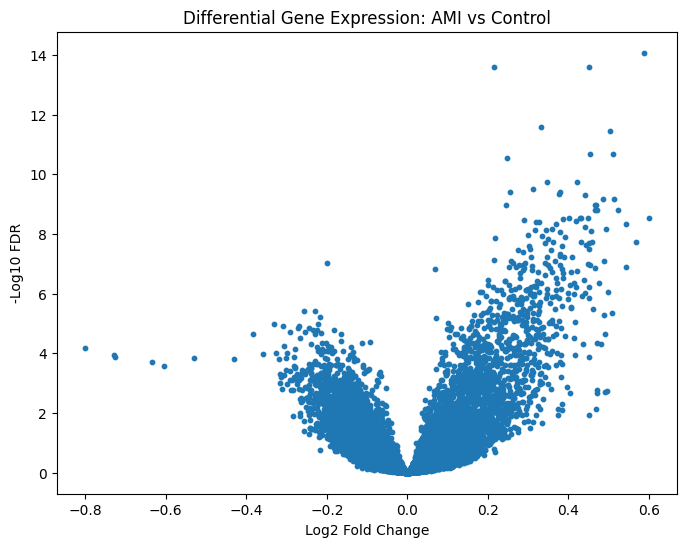

In [15]:
plt.figure(figsize=(8,6))


plt.scatter(
    deg["logFC"],
    -np.log10(deg["adjusted_pvalue"]),
    s=10
)


plt.xlabel("Log2 Fold Change")

plt.ylabel("-Log10 FDR")

plt.title(
    "Differential Gene Expression: AMI vs Control"
)


plt.show()

In [16]:
# Select top 50 DEGs by adjusted p-value

top_genes = (
    DEG
    .sort_values("adjusted_pvalue")
    .head(50)
    ["Gene"]
)


top_genes.head()

,Gene


In [17]:
heatmap_data = expression.loc[top_genes]


heatmap_data.head()

,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,GSM1620824,GSM1620825,GSM1620826,GSM1620827,GSM1620828,...,GSM1620908,GSM1620909,GSM1620910,GSM1620911,GSM1620912,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
ID_REF,,,,,,,,,,,,,,,,,,,,,


In [19]:
print("Total significant DEGs:", len(DEG))

DEG.head()

Total significant DEGs: 0


,Gene,logFC,pvalue,adjusted_pvalue


In [20]:
DEG = deg[
    (deg.adjusted_pvalue < 0.05)
    &
    (abs(deg.logFC) > 0.5)
]


print(
    "Number of DEGs:",
    len(DEG)
)

DEG.head()

Number of DEGs: 16


,Gene,logFC,pvalue,adjusted_pvalue
368,1552772_at,0.543255,2.864243e-12,4.605955e-09
2548,1555756_a_at,0.507949,1.600451e-08,4.464523e-06
11290,201842_s_at,0.568815,1.615210e-11,1.796108e-08
13335,203888_at,0.502296,3.334722e-16,3.646519e-12
19550,210146_x_at,0.522314,6.491195e-13,1.543070e-09


In [21]:
top_genes = (
    DEG
    .sort_values("adjusted_pvalue")
    .head(50)
    ["Gene"]
)

print(top_genes)

25540     216248_s_at
13335       203888_at
49352       240103_at
19821     210423_s_at
19550     210146_x_at
25308       216016_at
368        1552772_at
11290     201842_s_at
24939     215646_s_at
2548     1555756_a_at
33849       224590_at
23517     214218_s_at
36925       227671_at
40846       231592_at
31008     221728_x_at
33847       224588_at
Name: Gene, dtype: object


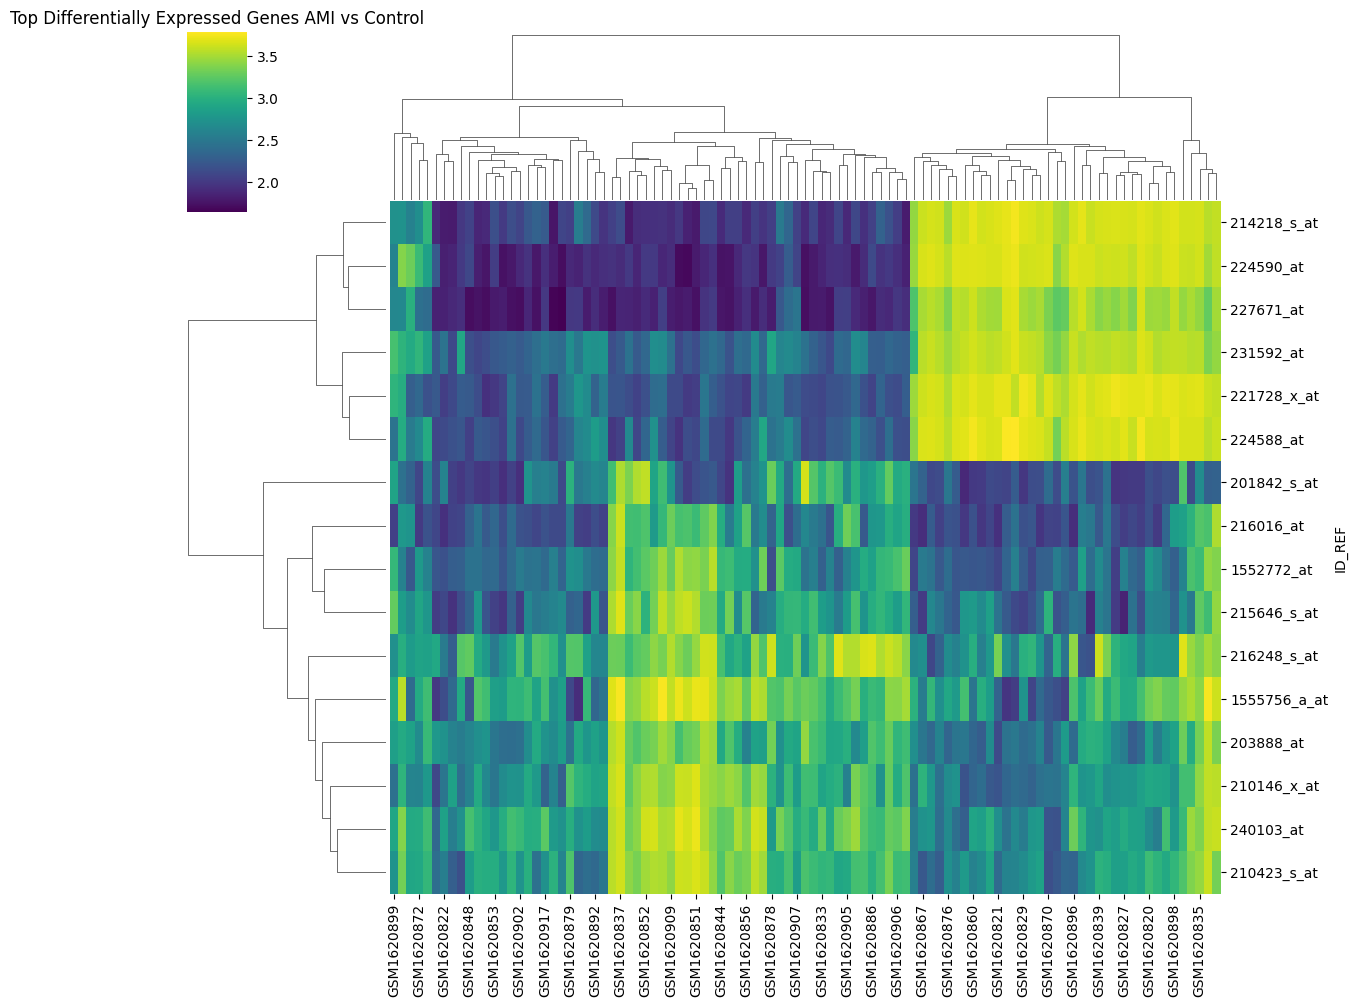

In [22]:
heatmap_data = expression.loc[top_genes]


sns.clustermap(
    heatmap_data,
    cmap="viridis",
    figsize=(12,10),
    col_cluster=True,
    row_cluster=True
)


plt.title(
    "Top Differentially Expressed Genes AMI vs Control"
)

plt.show()

In [23]:
genes = DEG["Gene"].tolist()

print("Genes for enrichment:", len(genes))

genes[:10]

Genes for enrichment: 16


['1552772_at',
 '1555756_a_at',
 '201842_s_at',
 '203888_at',
 '210146_x_at',
 '210423_s_at',
 '214218_s_at',
 '215646_s_at',
 '216016_at',
 '216248_s_at']

In [26]:
id="gpl570map"
platform = gse.gpls["GPL570"]

annotation = platform.table

annotation.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [27]:
annotation.columns

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')

In [28]:
probe_gene = annotation[
    [
        "ID",
        "Gene Symbol"
    ]
]


probe_gene.head()

,ID,Gene Symbol
0,1007_s_at,DDR1 /// MIR4640
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [29]:
DEG = DEG.merge(
    probe_gene,
    left_on="Gene",
    right_on="ID",
    how="left"
)


DEG.head()

,Gene,logFC,pvalue,adjusted_pvalue,ID,Gene Symbol
0,1552772_at,0.543255,2.864243e-12,4.605955e-09,1552772_at,CLEC4D
1,1555756_a_at,0.507949,1.600451e-08,4.464523e-06,1555756_a_at,CLEC7A
2,201842_s_at,0.568815,1.615210e-11,1.796108e-08,201842_s_at,EFEMP1
3,203888_at,0.502296,3.334722e-16,3.646519e-12,203888_at,THBD
4,210146_x_at,0.522314,6.491195e-13,1.543070e-09,210146_x_at,LILRB2


In [30]:
DEG = DEG[
    DEG["Gene Symbol"].notna()
]


genes = DEG["Gene Symbol"].tolist()


print(
    "Genes for enrichment:",
    len(genes)
)


genes[:20]

Genes for enrichment: 15


['CLEC4D',
 'CLEC7A',
 'EFEMP1',
 'THBD',
 'LILRB2',
 'SLC11A1',
 'XIST',
 'VCAN',
 'NLRP3',
 'NR4A2',
 'XIST',
 'XIST',
 'XIST',
 'XIST',
 'TSIX']

In [31]:
enrichment = gp.enrichr(
    gene_list=genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "KEGG_2021_Human"
    ],
    organism="human",
    outdir="results/enrichment",
    cutoff=0.5
)


print("Done")

Done


In [32]:
pathways = enrichment.results

print(pathways.shape)
pathways.head(20)

(291, 10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,4/320,0.000019,0.002202,0,0,35.575045,385.956461,CLEC7A;SLC11A1;NLRP3;LILRB2
1,GO_Biological_Process_2023,Positive Regulation Of Adaptive Immune Respons...,2/14,0.000025,0.002202,0,0,369.944444,3921.129905,CLEC7A;SLC11A1
2,GO_Biological_Process_2023,Defense Response To Protozoan (GO:0042832),2/15,0.000029,0.002202,0,0,341.470085,3570.560667,CLEC7A;SLC11A1
3,GO_Biological_Process_2023,Antifungal Innate Immune Response (GO:0061760),2/16,0.000033,0.002202,0,0,317.063492,3273.111441,CLEC4D;CLEC7A
4,GO_Biological_Process_2023,Positive Regulation Of Leukocyte Activation (G...,2/20,0.000052,0.002786,0,0,246.555556,2432.238168,CLEC4D;CLEC7A
5,GO_Biological_Process_2023,Response To Lipopolysaccharide (GO:0032496),3/159,0.000078,0.003467,0,0,47.675481,451.179388,SLC11A1;NLRP3;LILRB2
6,GO_Biological_Process_2023,Defense Response To Fungus (GO:0050832),2/29,0.000111,0.004240,0,0,164.296296,1496.449021,CLEC4D;CLEC7A
7,GO_Biological_Process_2023,Positive Regulation Of Interleukin-1 Beta Prod...,2/57,0.000432,0.011219,0,0,80.541414,624.012495,CLEC7A;NLRP3
8,GO_Biological_Process_2023,Positive Regulation Of Type II Interferon Prod...,2/58,0.000447,0.011219,0,0,79.099206,610.086689,CLEC7A;SLC11A1
9,GO_Biological_Process_2023,Regulation Of Phagocytosis (GO:0050764),2/58,0.000447,0.011219,0,0,79.099206,610.086689,CLEC7A;SLC11A1


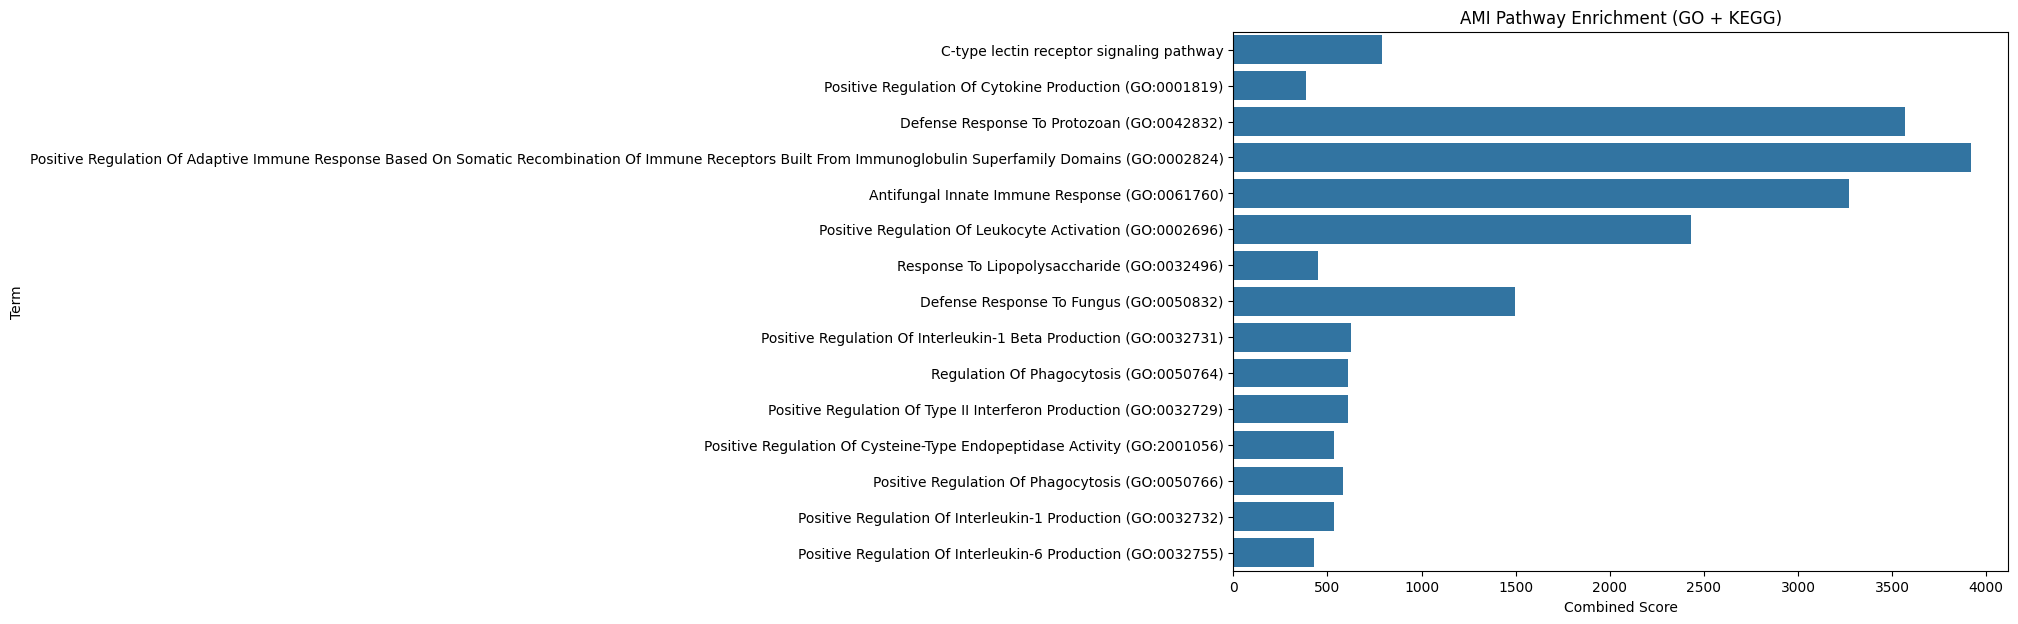

In [33]:
top_pathways = (
    pathways
    .sort_values("Adjusted P-value")
    .head(15)
)


plt.figure(figsize=(10,7))

sns.barplot(
    data=top_pathways,
    x="Combined Score",
    y="Term"
)

plt.title("AMI Pathway Enrichment (GO + KEGG)")
plt.show()

In [34]:
import os

os.makedirs("results", exist_ok=True)

pathways.to_csv(
    "results/AMI_pathway_enrichment.csv",
    index=False
)

In [35]:
top_features = (
    DEG.sort_values("adjusted_pvalue")
    .head(30)["Gene Symbol"]
    .tolist()
)

In [37]:
platform = gse.gpls["GPL570"]
annotation = platform.table

In [38]:
mapping = annotation[["ID", "Gene Symbol"]].dropna()

In [39]:
expression = expression.copy()

expression["Gene Symbol"] = expression.index

expression = expression.reset_index(drop=True)

expression = expression.merge(
    mapping,
    left_on="Gene Symbol",
    right_on="ID",
    how="left"
)


In [41]:
samples = {}

for gsm_name, gsm in gse.gsms.items():
    samples[gsm_name] = gsm.table


In [42]:
expression = pd.concat(
    [x.set_index("ID_REF")["VALUE"] for x in samples.values()],
    axis=1
)

expression.columns = samples.keys()

In [43]:
platform = gse.gpls["GPL570"]
mapping = platform.table[["ID", "Gene Symbol"]].dropna()

In [46]:
expression = expression.reset_index()

In [47]:
print(expression.columns)

Index(['ID_REF', 'GSM1620819', 'GSM1620820', 'GSM1620821', 'GSM1620822',
       'GSM1620823', 'GSM1620824', 'GSM1620825', 'GSM1620826', 'GSM1620827',
       'GSM1620828', 'GSM1620829', 'GSM1620830', 'GSM1620831', 'GSM1620832',
       'GSM1620833', 'GSM1620834', 'GSM1620835', 'GSM1620836', 'GSM1620837',
       'GSM1620838', 'GSM1620839', 'GSM1620840', 'GSM1620841', 'GSM1620842',
       'GSM1620843', 'GSM1620844', 'GSM1620845', 'GSM1620846', 'GSM1620847',
       'GSM1620848', 'GSM1620849', 'GSM1620850', 'GSM1620851', 'GSM1620852',
       'GSM1620853', 'GSM1620854', 'GSM1620855', 'GSM1620856', 'GSM1620857',
       'GSM1620858', 'GSM1620859', 'GSM1620860', 'GSM1620861', 'GSM1620862',
       'GSM1620863', 'GSM1620864', 'GSM1620865', 'GSM1620866', 'GSM1620867',
       'GSM1620868', 'GSM1620869', 'GSM1620870', 'GSM1620871', 'GSM1620872',
       'GSM1620873', 'GSM1620874', 'GSM1620875', 'GSM1620876', 'GSM1620877',
       'GSM1620878', 'GSM1620879', 'GSM1620880', 'GSM1620881', 'GSM1620882',
   

In [48]:
expression = expression.rename(columns={"ID_REF": "ID"})

In [49]:
print(expression.columns[:5])

Index(['ID', 'GSM1620819', 'GSM1620820', 'GSM1620821', 'GSM1620822'], dtype='object')


In [50]:
expression = expression.merge(
    mapping,
    on="ID",
    how="left"
)

In [51]:
print(expression.head())
print(expression.columns)

          ID  GSM1620819  GSM1620820  GSM1620821  GSM1620822  GSM1620823  \
0  1007_s_at    5.866378    4.948736    5.148384    5.064419    5.017833   
1    1053_at    8.225790    7.525865    7.764637    7.198461    7.831450   
2     117_at    6.179732    6.628137    5.859151    5.974135    6.793079   
3     121_at    6.179478    6.582889    6.602135    6.545905    5.911542   
4  1255_g_at    2.792048    2.695714    2.580181    2.712124    2.723687   

   GSM1620824  GSM1620825  GSM1620826  GSM1620827  ...  GSM1620909  \
0    5.116154    5.431328    5.235271    5.773528  ...    5.057716   
1    7.203592    7.694551    7.760259    8.279814  ...    7.105538   
2    6.435229    6.320546    6.483590    6.387779  ...    7.441940   
3    6.285420    6.562316    6.345888    6.272806  ...    6.317523   
4    2.706684    2.674747    2.635150    2.696649  ...    2.714103   

   GSM1620910  GSM1620911  GSM1620912  GSM1620913  GSM1620914  GSM1620915  \
0    5.996493    5.343133    5.558892    6.47

In [52]:
expression = expression.dropna(subset=["Gene Symbol"])

expression = expression.groupby("Gene Symbol").mean(numeric_only=True)

In [53]:
X = expression.loc[top_features].T
y = (metadata["group"] == "AMI").astype(int)